In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


In [2]:
df = pd.read_csv('C:\\Users\\吉吉\\.cache\\kagglehub\\datasets\\blastchar\\telco-customer-churn\\versions\\1\\WA_Fn-UseC_-Telco-Customer-Churn.csv')
title = df.head(0)
describe = df.describe()
print(describe)
print('Dataset shape:', df.shape)
print('Colums:', df.columns.tolist())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000
Dataset shape: (7043, 21)
Colums: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
#Checking missing values
missing_values = df.isnull().sum()
print('Missing Values')
print(missing_values)

#Checking duplicate values
duplicate_values = df.duplicated().sum()
print('Duplicate Values')
print(duplicate_values)

Missing Values
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Duplicate Values
0


In [4]:
print('The frequence of the', df['Churn'].value_counts())
print('The percentage of the', df['Churn'].value_counts(normalize = True)*100)


The frequence of the Churn
No     5174
Yes    1869
Name: count, dtype: int64
The percentage of the Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [5]:
target = 'Churn'
print("Classes:", df[target].unique())

Classes: ['No' 'Yes']


In [6]:
#Relationship PaperlessBilling between Churn
print(df.groupby("PaperlessBilling")["Churn"].value_counts(normalize=True) * 100)

# relationship PaymentMethod between Churn
print(df.groupby("PaymentMethod")["Churn"].value_counts(normalize=True) * 100)

PaperlessBilling  Churn
No                No       83.669916
                  Yes      16.330084
Yes               No       66.434908
                  Yes      33.565092
Name: proportion, dtype: float64
PaymentMethod              Churn
Bank transfer (automatic)  No       83.290155
                           Yes      16.709845
Credit card (automatic)    No       84.756899
                           Yes      15.243101
Electronic check           No       54.714588
                           Yes      45.285412
Mailed check               No       80.893300
                           Yes      19.106700
Name: proportion, dtype: float64


In [40]:
#we find that the TotalCharges is the object type
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(df["TotalCharges"].isna().sum()) 
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

#select 
binary_cols = ['SeniorCitizen']
df[binary_cols] = df[binary_cols].astype('category')

#customerID has no contribute to target
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_cols.remove('customerID')

numerical_cols = df.select_dtypes(include = [np.number]).columns.tolist()
if target in categorical_cols:
    categorical_cols.remove(target)

x = df[categorical_cols + numerical_cols]
y = df[target]

preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop = 'first', sparse_output = False), categorical_cols)
    ])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LogisticRegression())
])

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42
)

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print(f"R² score: {classification_report(y_test, y_pred)}")

0
R² score:               precision    recall  f1-score   support

          No       0.83      0.89      0.86      1033
         Yes       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [51]:
features_names = model.named_steps['preprocessor'].get_feature_names_out()
coefficient = model.named_steps['regressor'].coef_[0]
features_importance = pd.DataFrame({
    'feature': features_names,
    'coefficient': coefficient,
    'abs_coefficient': abs(coefficient)
}).sort_values(by = 'abs_coefficient', ascending = False)

print(features_importance.head(15))

                                feature  coefficient  abs_coefficient
0                           num__tenure    -1.448308         1.448308
25               cat__Contract_Two year    -1.288951         1.288951
10     cat__InternetService_Fiber optic     1.020333         1.020333
24               cat__Contract_One year    -0.752307         0.752307
2                     num__TotalCharges     0.693877         0.693877
7                 cat__PhoneService_Yes    -0.512750         0.512750
13              cat__OnlineSecurity_Yes    -0.399771         0.399771
19                 cat__TechSupport_Yes    -0.374381         0.374381
23             cat__StreamingMovies_Yes     0.341719         0.341719
21                 cat__StreamingTV_Yes     0.324654         0.324654
1                   num__MonthlyCharges    -0.294289         0.294289
26            cat__PaperlessBilling_Yes     0.273253         0.273253
28  cat__PaymentMethod_Electronic check     0.269831         0.269831
9                cat

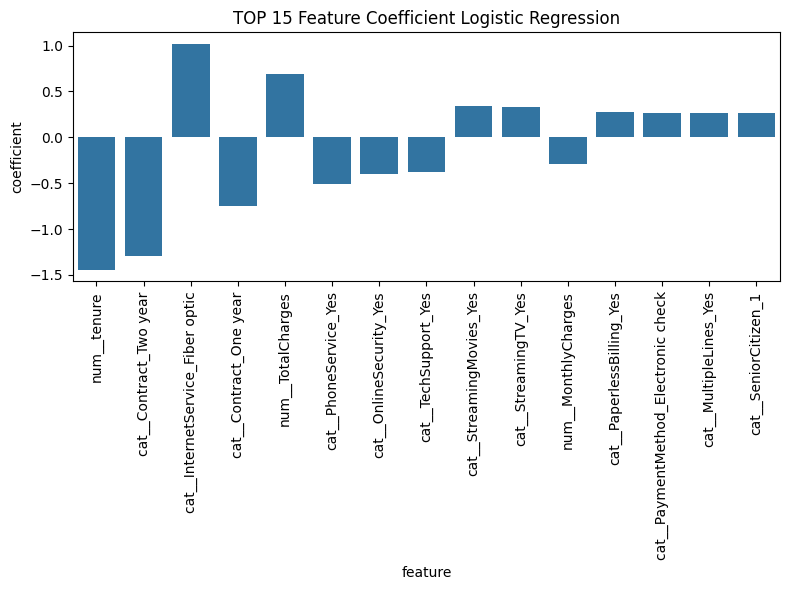

In [65]:
plt.figure(figsize = (8, 6))
sns.barplot(data = features_importance.head(15), x = 'feature', y = 'coefficient')
plt.xticks(rotation = 90)
plt.title('TOP 15 Feature Coefficient Logistic Regression')
plt.tight_layout()
plt.show()
